<a href="https://colab.research.google.com/github/ElpoderdelComputo/Procesamiento_imagenes/blob/main/Detecci%C3%B3n_de_bordes_Canny.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Detección de BORDES - Algoritmo Canny**

1.   Autor: Jose Rodriguez Rosales
2.   YouTube: [El Poder del Cómputo](https://www.youtube.com/@elpoderdelcomputo)

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
from skimage import util, data
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Configuración estética
plt.rcParams['figure.figsize'] = [16, 8]
plt.rcParams['font.size'] = 12
plt.rcParams['font.weight'] = 'bold'

print("="*70)
print("🎬 VIDEO 4: DETECCIÓN DE BORDES - ALGORITMO CANNY PASO A PASO")
print("="*70)

🎬 VIDEO 4: DETECCIÓN DE BORDES - ALGORITMO CANNY PASO A PASO



🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍
🔍 2. ¿QUÉ ES REALMENTE UN BORDE?
🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍🔍

   Vamos a crear una imagen SIMPLE para entender el concepto...


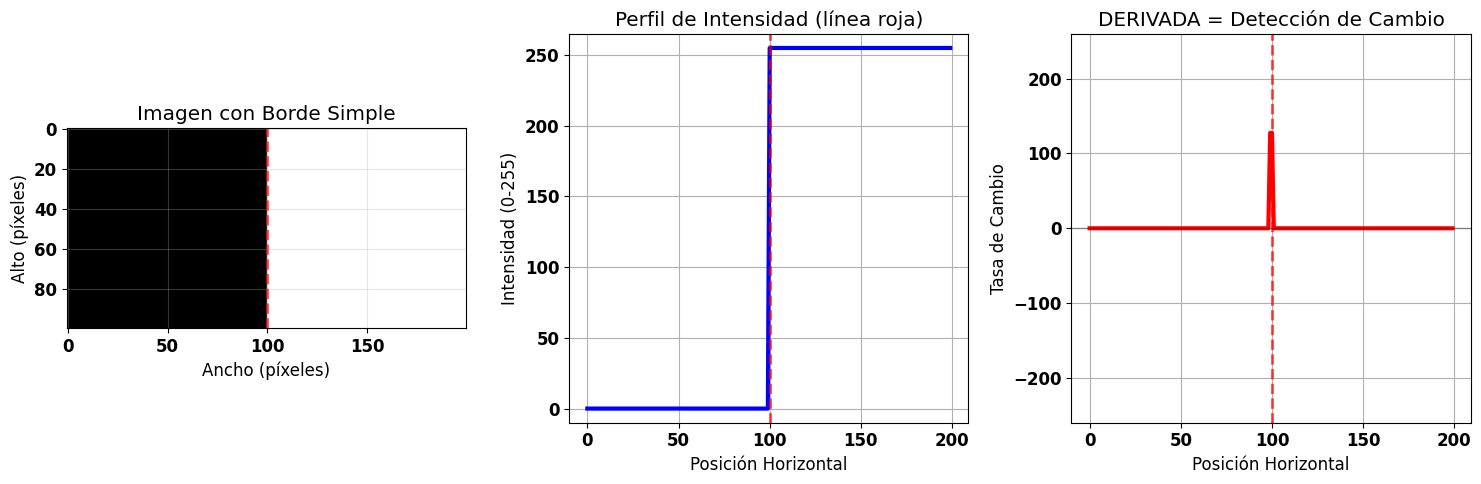


   💡 CONCLUSIÓN: Un borde es un CAMBIO BRUSCO DE INTENSIDAD
   La derivada (o gradiente) es máxima justo en el borde!


In [3]:
# ============================================================================
# 2. ¿QUÉ ES UN BORDE? - EXPLICACIÓN VISUAL
# ============================================================================
print("\n" + "🔍"*30)
print("🔍 2. ¿QUÉ ES REALMENTE UN BORDE?")
print("🔍"*30)

# Crear una imagen simple para explicar
print("\n   Vamos a crear una imagen SIMPLE para entender el concepto...")

# Crear una imagen con un borde perfecto
img_simple = np.zeros((100, 200), dtype=np.uint8)
img_simple[:, 100:] = 255  # Borde vertical en la mitad

# Crear perfil de intensidad
x_positions = np.arange(200)
intensities = img_simple[50, :]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Imagen original
axes[0].imshow(img_simple, cmap='gray')
axes[0].axvline(x=100, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[0].set_title('Imagen con Borde Simple')
axes[0].set_xlabel('Ancho (píxeles)')
axes[0].set_ylabel('Alto (píxeles)')
axes[0].grid(True, alpha=0.3)

# Perfil de intensidad
axes[1].plot(x_positions, intensities, 'b-', linewidth=3)
axes[1].axvline(x=100, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[1].set_title('Perfil de Intensidad (línea roja)')
axes[1].set_xlabel('Posición Horizontal')
axes[1].set_ylabel('Intensidad (0-255)')
axes[1].grid(True)
axes[1].set_ylim(-10, 265)

# Derivada (cambio de intensidad)
gradient = np.gradient(intensities)
axes[2].plot(x_positions, gradient, 'r-', linewidth=3)
axes[2].axvline(x=100, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.3)
axes[2].set_title('DERIVADA = Detección de Cambio')
axes[2].set_xlabel('Posición Horizontal')
axes[2].set_ylabel('Tasa de Cambio')
axes[2].grid(True)
axes[2].set_ylim(-260, 260)

plt.tight_layout()
plt.show()

print("\n   💡 CONCLUSIÓN: Un borde es un CAMBIO BRUSCO DE INTENSIDAD")
print("   La derivada (o gradiente) es máxima justo en el borde!")




🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️
🖼️ 1. CARGAMOS LA IMAGEN DE EJEMPLO: Lenna.png
🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️🖼️
Imagen 'Lenna.png' cargada exitosamente. Dimensiones: (512, 512)


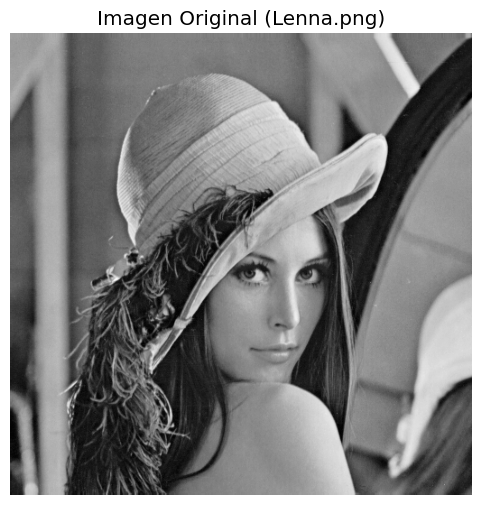

In [4]:
print("\n\n" + "🖼️"*30)
print("🖼️ 1. CARGAMOS LA IMAGEN DE EJEMPLO: Lenna.png")
print("🖼️"*30)

# Cargar la imagen
img_lena = cv2.imread('Lenna.png', cv2.IMREAD_GRAYSCALE)

# Verificar si la imagen se cargó correctamente
if img_lena is None:
    print("Error: No se pudo cargar la imagen. Asegúrate de que 'Lenna.png' esté en la ruta correcta.")
else:
    print(f"Imagen 'Lenna.png' cargada exitosamente. Dimensiones: {img_lena.shape}")

    # Mostrar la imagen original
    plt.figure(figsize=(6,6))
    plt.imshow(img_lena, cmap='gray')
    plt.title('Imagen Original (Lenna.png)')
    plt.axis('off')
    plt.show()


🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮
🧮 3. SOBEL - El detector clásico de bordes
🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮🧮


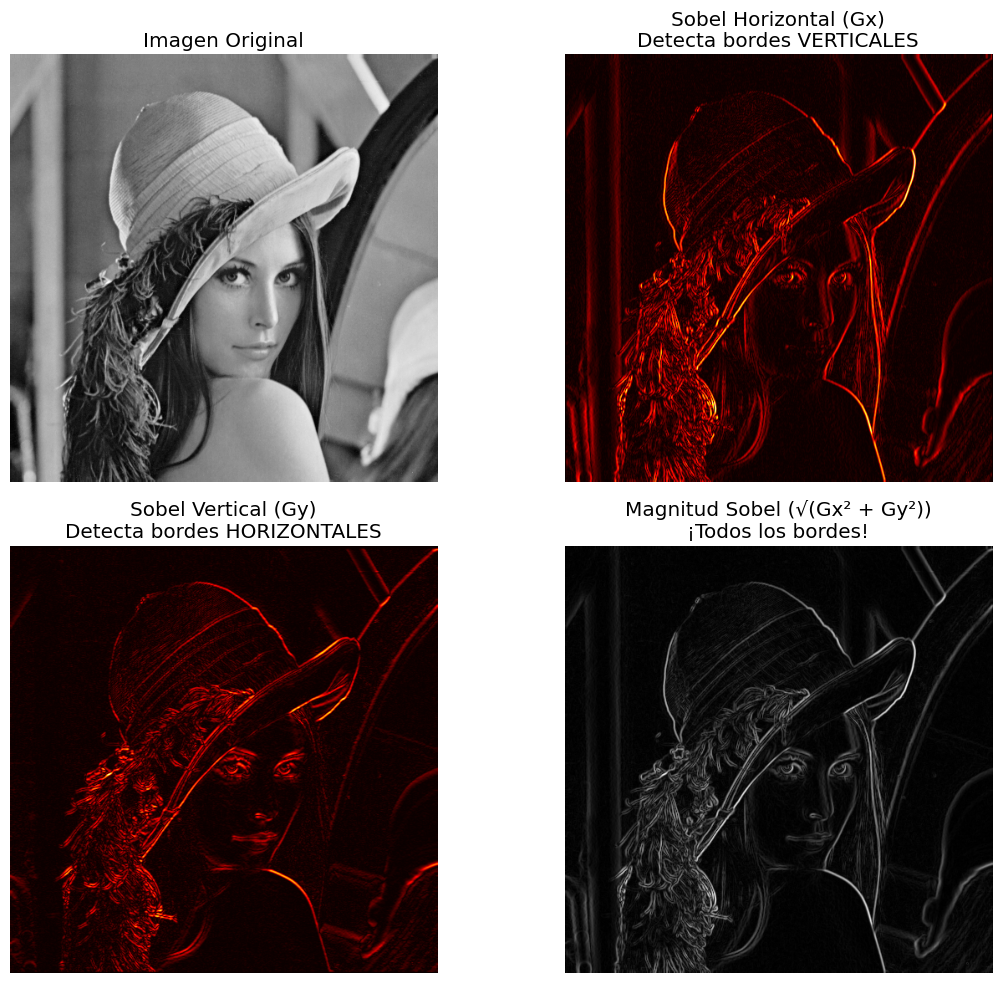


   🤔 Problema con Sobel: Mucho RUIDO y bordes muy GRUESOS
   Necesitamos algo más inteligente...


In [5]:
# ============================================================================
# 3. OPERADORES SIMPLES: SOBEL - El "abuelo" de los detectores de bordes
# ============================================================================
print("\n" + "🧮"*30)
print("🧮 3. SOBEL - El detector clásico de bordes")
print("🧮"*30)

# Aplicar Sobel a la imagen del edificio
sobel_x = cv2.Sobel(img_lena, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_lena, cv2.CV_64F, 0, 1, ksize=3)
sobel_magnitud = np.sqrt(sobel_x**2 + sobel_y**2)
sobel_magnitud = np.uint8(sobel_magnitud / sobel_magnitud.max() * 255)

# Visualizar Sobel
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(img_lena, cmap='gray')
axes[0, 0].set_title('Imagen Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(np.abs(sobel_x), cmap='hot')
axes[0, 1].set_title('Sobel Horizontal (Gx)\nDetecta bordes VERTICALES')
axes[0, 1].axis('off')

axes[1, 0].imshow(np.abs(sobel_y), cmap='hot')
axes[1, 0].set_title('Sobel Vertical (Gy)\nDetecta bordes HORIZONTALES')
axes[1, 0].axis('off')

axes[1, 1].imshow(sobel_magnitud, cmap='gray')
axes[1, 1].set_title('Magnitud Sobel (√(Gx² + Gy²))\n¡Todos los bordes!')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("\n   🤔 Problema con Sobel: Mucho RUIDO y bordes muy GRUESOS")
print("   Necesitamos algo más inteligente...")


⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐
⭐ 4. CANNY - El algoritmo que lo cambió todo
⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐

   🎯 CANNY funciona en 4 PASOS:
   1. Suavizado Gaussiano (¡del video anterior!)
   2. Cálculo del Gradiente (parecido a Sobel)
   3. Supresión de No-Máximos (hace bordes finos)
   4. Histéresis con Umbrales (elimina ruido)

   🚀 Implementando CANNY paso a paso...

   ⚙️  Parámetros: σ=1.5, Umbral bajo=50, Umbral alto=150
   🔸 PASO 1: Suavizado Gaussiano
   🔸 PASO 2: Cálculo del Gradiente
   🔸 PASO 3: Supresión de No-Máximos (interno en cv2.Canny)
   🔸 PASO 4: Histéresis con Umbrales


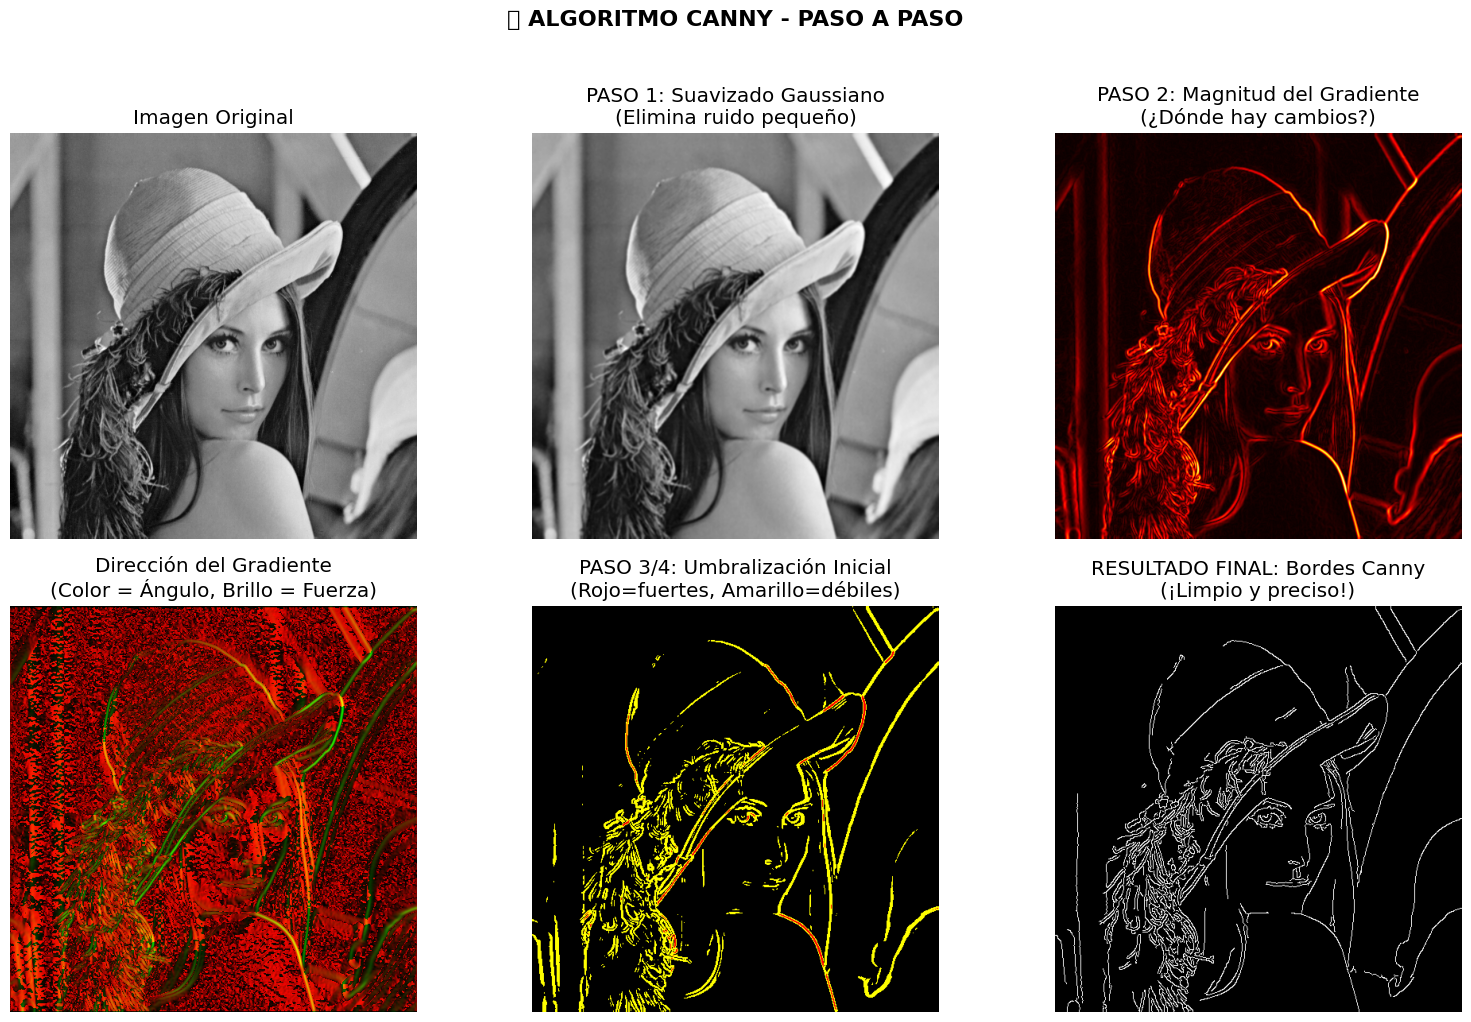

In [6]:
# ============================================================================
# 4. EL ALGORITMO CANNY - ¡Nuestro HÉROE!
# ============================================================================
print("\n" + "⭐"*30)
print("⭐ 4. CANNY - El algoritmo que lo cambió todo")
print("⭐"*30)

print("\n   🎯 CANNY funciona en 4 PASOS:")
print("   1. Suavizado Gaussiano (¡del video anterior!)")
print("   2. Cálculo del Gradiente (parecido a Sobel)")
print("   3. Supresión de No-Máximos (hace bordes finos)")
print("   4. Histéresis con Umbrales (elimina ruido)")

# Vamos a implementar Canny paso a paso
def mostrar_pasos_canny(imagen, sigma=1.0, low_threshold=50, high_threshold=150):
    """
    Función que muestra visualmente cada paso del algoritmo Canny
    """
    print(f"\n   ⚙️  Parámetros: σ={sigma}, Umbral bajo={low_threshold}, Umbral alto={high_threshold}")

    # PASO 1: Suavizado Gaussiano
    print("   🔸 PASO 1: Suavizado Gaussiano")
    img_suavizada = cv2.GaussianBlur(imagen, (3, 3), sigmaX=sigma)

    # PASO 2: Gradiente (usando Sobel)
    print("   🔸 PASO 2: Cálculo del Gradiente")
    grad_x = cv2.Sobel(img_suavizada, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(img_suavizada, cv2.CV_64F, 0, 1, ksize=3)

    magnitud = np.sqrt(grad_x**2 + grad_y**2)
    direccion = np.arctan2(grad_y, grad_x) * 180 / np.pi

    # Normalizar para visualización
    magnitud_norm = np.uint8(magnitud / magnitud.max() * 255)

    # PASO 3: Supresión de No-Máximos (versión simplificada para visualización)
    # Nota: La supresión de no-máximos y el linking por histéresis se realizan internamente en cv2.Canny.
    magnitud_sup = np.zeros_like(magnitud_norm) # Placeholder si no se visualiza NMS paso a paso
    print("   🔸 PASO 3: Supresión de No-Máximos (interno en cv2.Canny)")

    # PASO 4: Histéresis de Umbrales
    print("   🔸 PASO 4: Histéresis con Umbrales")
    # Usamos la función Canny de OpenCV para el resultado final
    bordes_canny = cv2.Canny(img_suavizada, low_threshold, high_threshold)

    # Visualizar todos los pasos
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))

    axes[0, 0].imshow(imagen, cmap='gray')
    axes[0, 0].set_title('Imagen Original')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(img_suavizada, cmap='gray')
    axes[0, 1].set_title('PASO 1: Suavizado Gaussiano\n(Elimina ruido pequeño)')
    axes[0, 1].axis('off')

    axes[0, 2].imshow(magnitud_norm, cmap='hot')
    axes[0, 2].set_title('PASO 2: Magnitud del Gradiente\n(¿Dónde hay cambios?)')
    axes[0, 2].axis('off')

    # Visualización de la dirección del gradiente (codificada en color)
    direccion_color = np.zeros((*direccion.shape, 3))
    direccion_color[..., 0] = (direccion % 180) / 180.0  # Rojo: orientación
    direccion_color[..., 1] = magnitud_norm / 255.0      # Verde: magnitud
    axes[1, 0].imshow(direccion_color)
    axes[1, 0].set_title('Dirección del Gradiente\n(Color = Ángulo, Brillo = Fuerza)')
    axes[1, 0].axis('off')

    # Visualización de umbrales iniciales (candidatos a bordes fuertes y débiles)
    bordes_fuertes = magnitud_norm > high_threshold
    bordes_debiles = (magnitud_norm >= low_threshold) & (magnitud_norm <= high_threshold)

    img_umbrales = np.zeros((*magnitud_norm.shape, 3))
    img_umbrales[bordes_fuertes] = [1, 0, 0]      # Rojo: bordes fuertes
    img_umbrales[bordes_debiles] = [1, 1, 0]      # Amarillo: bordes débiles

    axes[1, 1].imshow(img_umbrales)
    axes[1, 1].set_title('PASO 3/4: Umbralización Inicial\n(Rojo=fuertes, Amarillo=débiles)')
    axes[1, 1].axis('off')

    axes[1, 2].imshow(bordes_canny, cmap='gray')
    axes[1, 2].set_title('RESULTADO FINAL: Bordes Canny\n(¡Limpio y preciso!)')
    axes[1, 2].axis('off')

    plt.suptitle('🎯 ALGORITMO CANNY - PASO A PASO', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    return bordes_canny

# Mostrar los pasos de Canny con la imagen del edificio
print("\n   🚀 Implementando CANNY paso a paso...")
bordes_finales = mostrar_pasos_canny(img_lena, sigma=1.5, low_threshold=50, high_threshold=150)


✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨
✨ 5. ¡EL MOMENTO MÁGICO! Uniendo ambos videos
✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨✨

   ⚠️  ESCENARIO: ¿Qué pasa si aplicamos Canny a una imagen CON RUIDO?
   Spoiler: ¡Resultados DESASTROSOS!


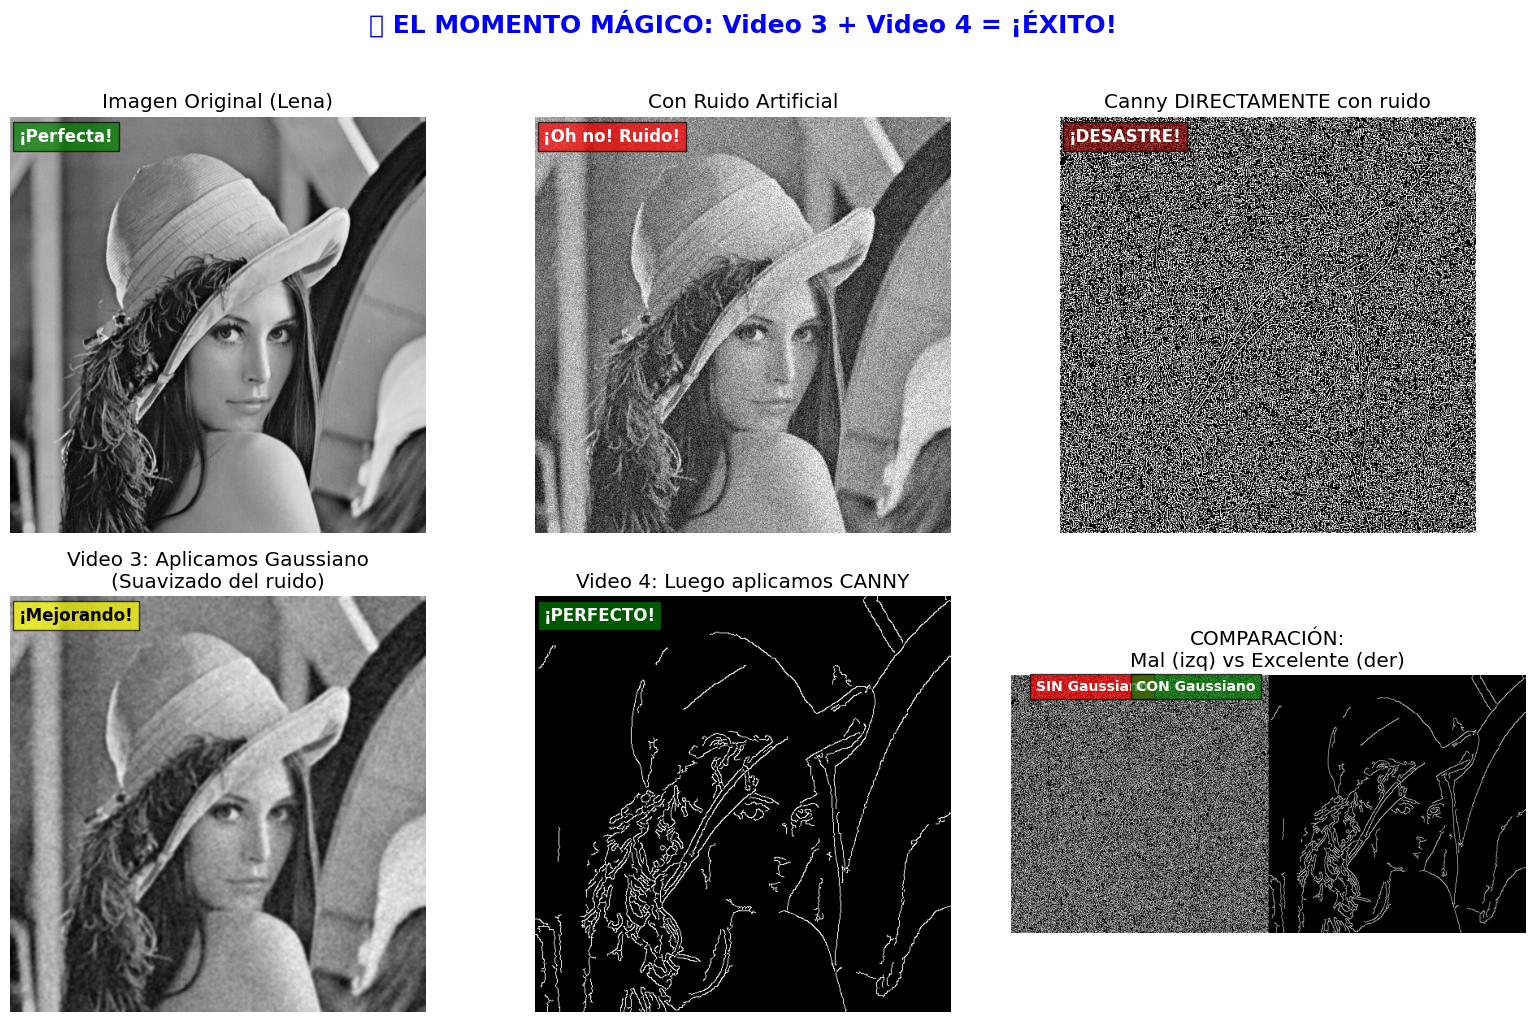


   🎉 ¡MORALEJA! El suavizado Gaussiano NO es opcional,
   es ESENCIAL para una buena detección de bordes con Canny.


In [7]:
# ============================================================================
# 5. ¡EL MOMENTO MÁGICO! Ruido vs Gaussiano + Canny
# ============================================================================
print("\n" + "✨"*40)
print("✨ 5. ¡EL MOMENTO MÁGICO! Uniendo ambos videos")
print("✨"*40)

print("\n   ⚠️  ESCENARIO: ¿Qué pasa si aplicamos Canny a una imagen CON RUIDO?")
print("   Spoiler: ¡Resultados DESASTROSOS!")

# Crear imagen con ruido
img_lena_ruidosa = util.random_noise(img_lena, mode='gaussian', var=0.01)
img_lena_ruidosa = (img_lena_ruidosa * 255).astype(np.uint8)

# Aplicar Canny directamente a la imagen con ruido (MALO)
canny_con_ruido = cv2.Canny(img_lena_ruidosa, 50, 150)

# Aplicar Gaussiano primero (como en el video 3) y luego Canny (CORRECTO)
img_suavizada = cv2.GaussianBlur(img_lena_ruidosa, (5, 5), sigmaX=2.0)
canny_correcto = cv2.Canny(img_suavizada, 50, 150)

# Visualización dramática del "momento mágico"
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].imshow(img_lena, cmap='gray')
axes[0, 0].set_title('Imagen Original (Lena)')
axes[0, 0].axis('off')
axes[0, 0].text(10, 30, '¡Perfecta!', color='white', fontsize=12, fontweight='bold',
                bbox=dict(facecolor='green', alpha=0.7))

axes[0, 1].imshow(img_lena_ruidosa, cmap='gray')
axes[0, 1].set_title('Con Ruido Artificial')
axes[0, 1].axis('off')
axes[0, 1].text(10, 30, '¡Oh no! Ruido!', color='white', fontsize=12, fontweight='bold',
                bbox=dict(facecolor='red', alpha=0.7))

axes[0, 2].imshow(canny_con_ruido, cmap='gray')
axes[0, 2].set_title('Canny DIRECTAMENTE con ruido')
axes[0, 2].axis('off')
axes[0, 2].text(10, 30, '¡DESASTRE!', color='white', fontsize=12, fontweight='bold',
                bbox=dict(facecolor='darkred', alpha=0.7))

axes[1, 0].imshow(img_suavizada, cmap='gray')
axes[1, 0].set_title('Video 3: Aplicamos Gaussiano\n(Suavizado del ruido)')
axes[1, 0].axis('off')
axes[1, 0].text(10, 30, '¡Mejorando!', color='black', fontsize=12, fontweight='bold',
                bbox=dict(facecolor='yellow', alpha=0.7))

axes[1, 1].imshow(canny_correcto, cmap='gray')
axes[1, 1].set_title('Video 4: Luego aplicamos CANNY')
axes[1, 1].axis('off')
axes[1, 1].text(10, 30, '¡PERFECTO!', color='white', fontsize=12, fontweight='bold',
                bbox=dict(facecolor='green', alpha=0.7))

# Comparación lado a lado
comparacion = np.hstack((canny_con_ruido, canny_correcto))
axes[1, 2].imshow(comparacion, cmap='gray')
axes[1, 2].set_title('COMPARACIÓN:\nMal (izq) vs Excelente (der)')
axes[1, 2].axis('off')
axes[1, 2].text(50, 30, 'SIN Gaussiano', color='white', fontsize=10,
                bbox=dict(facecolor='red', alpha=0.7))
axes[1, 2].text(250, 30, 'CON Gaussiano', color='white', fontsize=10,
                bbox=dict(facecolor='green', alpha=0.7))

plt.suptitle('🎩 EL MOMENTO MÁGICO: Video 3 + Video 4 = ¡ÉXITO!',
             fontsize=18, fontweight='bold', y=1.02, color='blue')
plt.tight_layout()
plt.show()

print("\n   🎉 ¡MORALEJA! El suavizado Gaussiano NO es opcional,")
print("   es ESENCIAL para una buena detección de bordes con Canny.")


🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮
🎮 6. LABORATORIO: Jugando con los parámetros de Canny
🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮🎮

   Los dos parámetros MÁS importantes de Canny:
   • UMBRAL BAJO: Detecta bordes débiles
   • UMBRAL ALTO: Detecta solo bordes fuertes

   💡 Regla práctica: Umbral Alto ≈ 3 × Umbral Bajo

   Probando diferentes combinaciones...

   Probando: bajo=10, alto=30 - Muy sensible (mucho ruido)


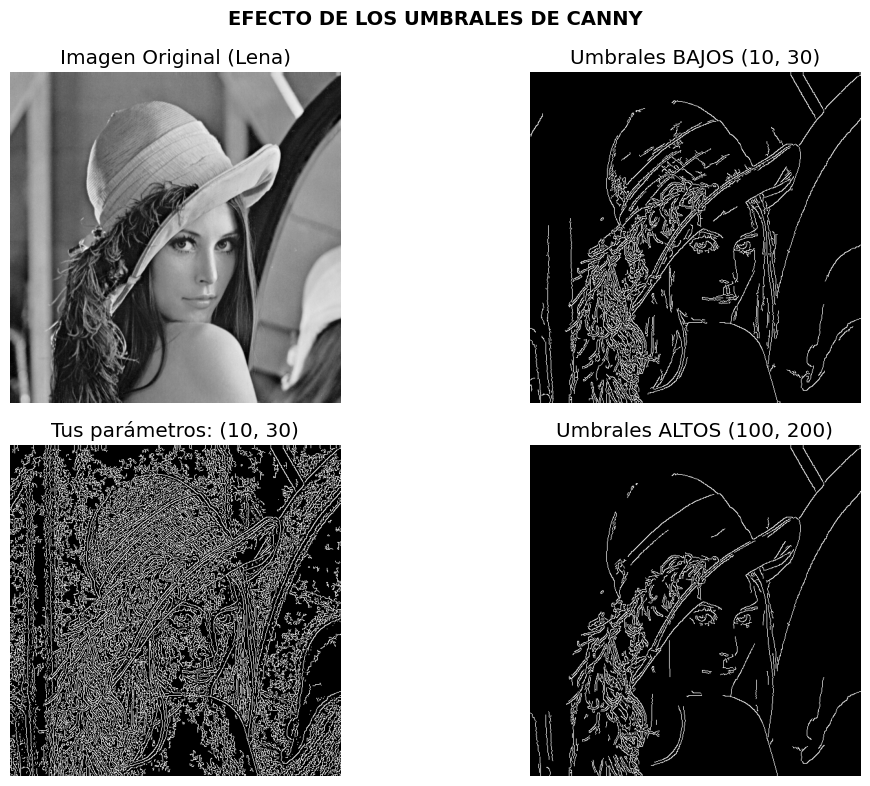


   Con umbrales (10, 30):
   • Bordes detectados: 68,248 píxeles
   • Relación Alto/Bajo: 3.0x

   Probando: bajo=50, alto=150 - Balanceado (recomendado)


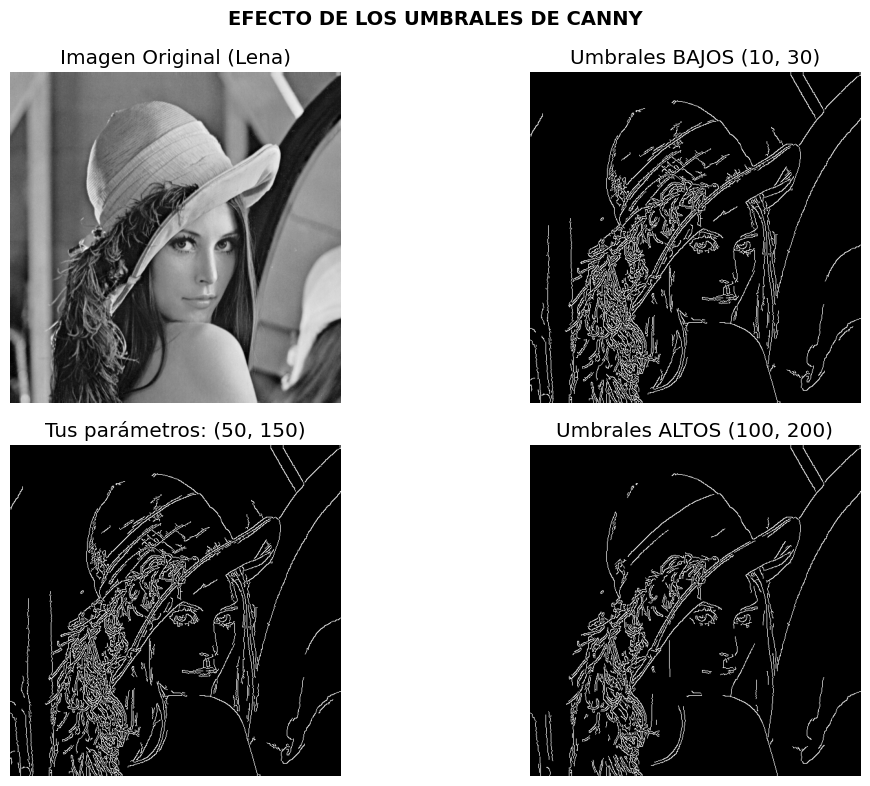


   Con umbrales (50, 150):
   • Bordes detectados: 20,598 píxeles
   • Relación Alto/Bajo: 3.0x

   Probando: bajo=100, alto=200 - Muy estricto (pocos bordes)


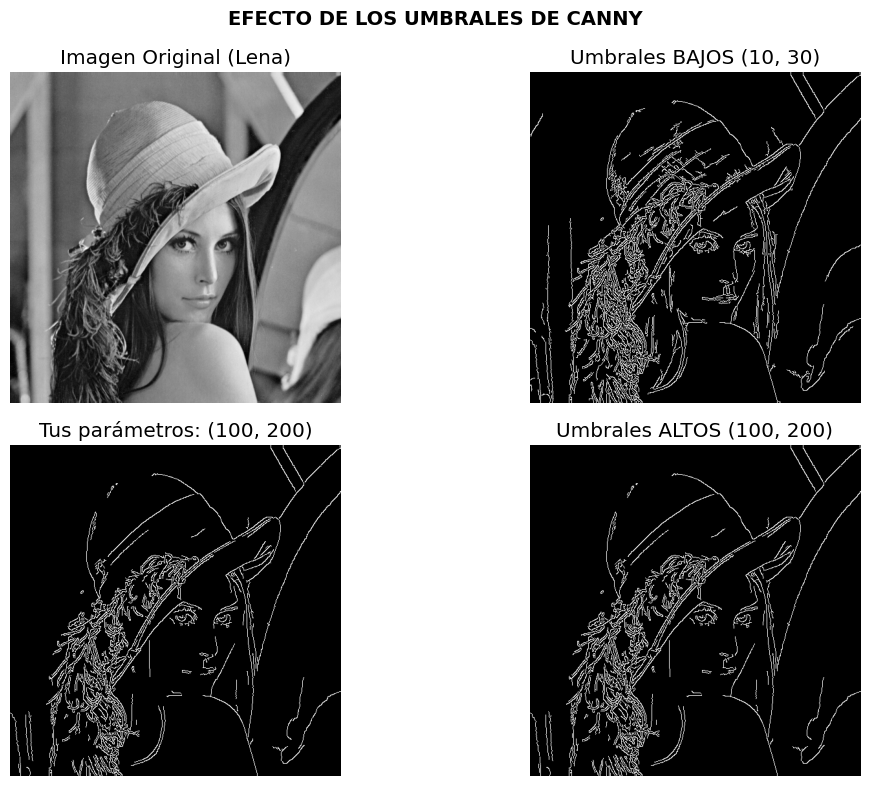


   Con umbrales (100, 200):
   • Bordes detectados: 14,167 píxeles
   • Relación Alto/Bajo: 2.0x


In [9]:
# ============================================================================
# 6. JUGANDO CON LOS PARÁMETROS - Interactividad
# ============================================================================
print("\n" + "🎮"*30)
print("🎮 6. LABORATORIO: Jugando con los parámetros de Canny")
print("🎮"*30)

print("\n   Los dos parámetros MÁS importantes de Canny:")
print("   • UMBRAL BAJO: Detecta bordes débiles")
print("   • UMBRAL ALTO: Detecta solo bordes fuertes")
print("\n   💡 Regla práctica: Umbral Alto ≈ 3 × Umbral Bajo")

# Función interactiva para jugar con parámetros
def explorar_parametros_canny(umbral_bajo=10, umbral_alto=50):
    """Función interactiva para explorar cómo afectan los umbrales"""

    # Aplicar Canny con diferentes parámetros
    bordes_actual = cv2.Canny(img_lena, umbral_bajo, umbral_alto)
    bordes_suave = cv2.Canny(img_lena, 50, 150)    # Muy sensible
    bordes_fuerte = cv2.Canny(img_lena, 100, 200) # Muy estricto

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    axes[0, 0].imshow(img_lena, cmap='gray')
    axes[0, 0].set_title('Imagen Original (Lena)')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(bordes_suave, cmap='gray')
    axes[0, 1].set_title('Umbrales BAJOS (10, 30)')
    axes[0, 1].axis('off')

    axes[1, 0].imshow(bordes_actual, cmap='gray')
    axes[1, 0].set_title(f'Tus parámetros: ({umbral_bajo}, {umbral_alto})')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(bordes_fuerte, cmap='gray')
    axes[1, 1].set_title('Umbrales ALTOS (100, 200)')
    axes[1, 1].axis('off')

    plt.suptitle(f'EFECTO DE LOS UMBRALES DE CANNY', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Estadísticas simples
    bordes_pixels = np.sum(bordes_actual > 0)
    porcentaje = (bordes_pixels / bordes_actual.size) * 100

    print(f"\n   Con umbrales ({umbral_bajo}, {umbral_alto}):")
    print(f"   • Bordes detectados: {bordes_pixels:,} píxeles")
    print(f"   • Relación Alto/Bajo: {umbral_alto/umbral_bajo:.1f}x")

print("\n   Probando diferentes combinaciones...")

# Probar varias combinaciones de parámetros
combinaciones = [
    (10, 30, "Muy sensible (mucho ruido)"),
    (50, 150, "Balanceado (recomendado)"),
    (100, 200, "Muy estricto (pocos bordes)")
]

for bajo, alto, desc in combinaciones:
    print(f"\n   Probando: bajo={bajo}, alto={alto} - {desc}")
    explorar_parametros_canny(bajo, alto)


📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚
📚 8. RESUMEN Y CÓDIGO PARA TUS PROYECTOS
📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚📚


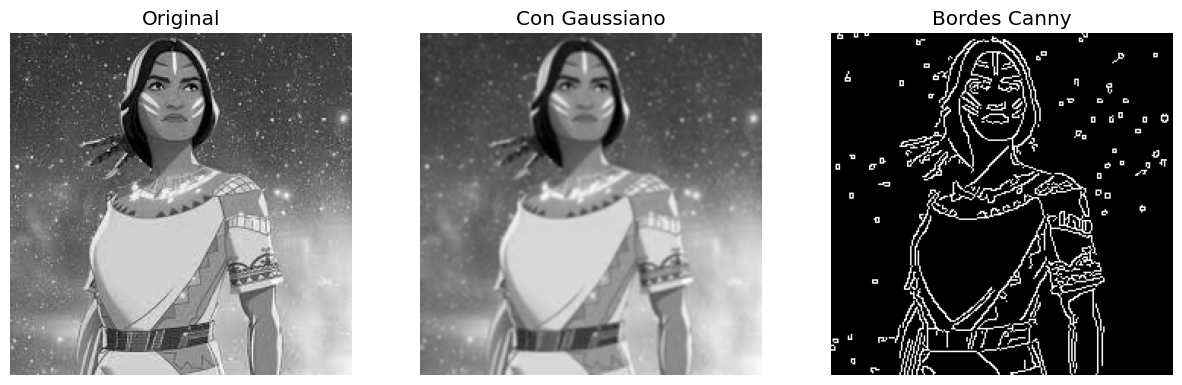

In [16]:
# ============================================================================
# 7. CÓDIGO FINAL: APLICACIÓN PRÁCTICA; Detección de bordes en diferentes imágenes
# ============================================================================
print("\n" + "📚"*40)
print("📚 8. RESUMEN Y CÓDIGO PARA TUS PROYECTOS")
print("📚"*40)

# ============================================================
# 🎯 CÓDIGO COMPLETO PARA DETECCIÓN DE BORDES CON CANNY
# ============================================================

# 1. CARGAR IMAGEN (siempre en escala de grises para bordes)
imagen = cv2.imread('/content/kahhori.jpg', cv2.IMREAD_GRAYSCALE)

# 2. PASO CRÍTICO: Suavizado Gaussiano (¡NO lo olvides!)
imagen_suavizada = cv2.GaussianBlur(imagen, (3, 3), sigmaX=1)

# 3. APLICAR CANNY con parámetros balanceados
umbral_bajo = 70    # Detecta bordes débiles
umbral_alto = 150   # Detecta bordes fuertes
bordes = cv2.Canny(imagen_suavizada, umbral_bajo, umbral_alto)

# 4. VISUALIZAR RESULTADOS

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(imagen, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(imagen_suavizada, cmap='gray')
axes[1].set_title('Con Gaussiano')
axes[1].axis('off')

axes[2].imshow(bordes, cmap='gray')
axes[2].set_title('Bordes Canny')
axes[2].axis('off')

plt.show()

# ⚡ CONSEJOS PRÁCTICOS:
# • Si hay mucho ruido: Aumenta sigma del Gaussiano (ej: sigmaX=2.0)
# • Si faltan bordes: Disminuye umbral_bajo (ej: 30)
# • Si hay demasiados bordes falsos: Aumenta umbral_bajo (ej: 70)
